# Smartphone Usage and Addiction Analysis
## Setup and Data Loading

* Importing libraries 
* Loading the raw dataset 
* Doing a quick initial inspection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv('Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')

display(df_raw.head())

print(f"Dataset Shape: {df_raw.shape}")

print("Column Names:")
print(df_raw.columns.tolist())

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


Dataset Shape: (7500, 16)
Column Names:
['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addiction_level', 'addicted_label']


## Cleaning and Data Quality

Check data quality, inspect ranges, standardize simple text formatting, and create the `df_clean` dataframe. Gender is inspected here, but all observed gender categories are retained so that the project does not lose rows before testing whether gender is useful for prediction.

In [2]:
print(f"Shape before cleaning: {df_raw.shape}")

# Keep df_raw as the original loaded file and use a working copy for checks/standardization.
df_working = df_raw.copy()
df_working.columns = df_working.columns.str.strip()

# Check data types
print("\n--- Data Types ---")
df_working.info()

# Check missing values
print("\n--- Missing Values ---")
print(df_working.isnull().sum())

# Check duplicates
print("\n--- Duplicate Checks ---")
print(f"Duplicate rows: {df_working.duplicated().sum()}")
print(f"Duplicate transaction_ids: {df_working['transaction_id'].duplicated().sum()}")
print(f"Duplicate user_ids: {df_working['user_id'].duplicated().sum()}")

# Check unique values in categorical columns.
categorical_cols = ['gender', 'stress_level', 'academic_work_impact', 'addiction_level']
print("\n--- Categorical Unique Values ---")
for col in categorical_cols:
    if col in df_working.columns:
        if df_working[col].dtype == 'object':
            df_working[col] = df_working[col].str.strip()
        print(f"{col}: {df_working[col].unique()}")

# Check basic numeric ranges
print("\n--- Numeric Ranges ---")
display(df_working.describe())

Shape before cleaning: (7500, 16)

--- Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact    

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [3]:
# Standardize gender labels while retaining all observed categories.
df_clean = df_working.copy()

gender_mapping = {
    'male': 'Male', 'Male': 'Male', 'M': 'Male',
    'female': 'Female', 'Female': 'Female', 'F': 'Female',
    'other': 'Other', 'Other': 'Other'
}

df_clean['gender'] = df_clean['gender'].replace(gender_mapping)

expected_gender_categories = ['Female', 'Male', 'Other']
unexpected_gender_mask = ~df_clean['gender'].isin(expected_gender_categories)
unexpected_gender_count = unexpected_gender_mask.sum()

print('Gender counts after standardization:')
display(df_clean['gender'].value_counts(dropna=False).rename('count').to_frame())

print(f"Unexpected or unclear gender values: {unexpected_gender_count}")
print('No gender rows are removed at this stage. Gender will be tested for relationship with the target and then excluded from modeling if it has weak predictive value.')
print(f"\nFinal df_clean shape: {df_clean.shape}")

Gender counts after standardization:


,count
gender,
Male,2553
Other,2486
Female,2461


Unexpected or unclear gender values: 0
No gender rows are removed at this stage. Gender will be tested for relationship with the target and then excluded from modeling if it has weak predictive value.

Final df_clean shape: (7500, 16)


### Person 1 Handoff to Person 2

1. Rows and columns after cleaning: 7,500 rows and 16 columns.
2. Missing values still exist in `addiction_level`: 819 missing values. No other columns have missing values.
3. Duplicate rows: 0. Duplicate `transaction_id`: 0. Duplicate `user_id`: 0.
4. Final unique values in `gender`: `Male`, `Female`, and `Other`.
5. No rows were removed for gender. The `Other` category is retained because it is an observed category, not a missing value to impute.
6. Gender will be tested against `addicted_label` before modeling. If it shows weak association, it will be excluded from the predictive feature set so the model focuses on behavioral usage variables.
7. `df_clean` is ready for Person 2 to continue preprocessing and feature preparation.

## 2. Preprocessing and Feature Preparation - Person 2

This section starts from `df_clean`, handles the remaining missing values, prepares useful engineered features, encodes `gender` for modeling, and creates `df_prepared`, `X`, and `y` for the next phases.

Important modeling rule: `transaction_id`, `user_id`, `addicted_label`, `addiction_level`, and the original text `gender` column are excluded from the feature matrix. `addiction_level` is excluded because it is closely related to the target and may leak target information.

In [4]:
# Start from the cleaned dataframe created by Person 1
df_prepared = df_clean.copy()

numeric_columns = [
    'age',
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time',
    'addicted_label'
]

categorical_columns = [
    'gender',
    'stress_level',
    'academic_work_impact',
    'addiction_level'
]

identifier_columns = ['transaction_id', 'user_id']

print('Missing values before preprocessing:')
display(df_prepared.isna().sum().to_frame('missing_count'))

# Do not impute the target. If target values are missing, remove those rows.
target_missing = df_prepared['addicted_label'].isna().sum()
if target_missing > 0:
    df_prepared = df_prepared.dropna(subset=['addicted_label']).copy()

# Numeric columns use median imputation if missing values are present.
numeric_imputation_values = {}
for col in numeric_columns:
    if col != 'addicted_label' and df_prepared[col].isna().sum() > 0:
        median_value = df_prepared[col].median()
        df_prepared[col] = df_prepared[col].fillna(median_value)
        numeric_imputation_values[col] = median_value

# Keep addiction_level missing in the source column, but create a display-only label for EDA.
# This avoids implying that missing values are a real addiction severity category.
df_prepared['addiction_level_display'] = df_prepared['addiction_level'].fillna('Not recorded')

print('\nNumeric columns:')
print(numeric_columns)

print('\nCategorical columns:')
print(categorical_columns)

print('\nNumeric imputation values used:')
print(numeric_imputation_values if numeric_imputation_values else 'No numeric imputation needed')

print('\nCategorical display handling used:')
print("Missing addiction_level values are shown as 'Not recorded' for EDA only; addiction_level is not used for modeling.")

print('\nMissing values after preprocessing:')
display(df_prepared.isna().sum().to_frame('missing_count'))

print('\nGender categories retained for diagnostic EDA:')
display(df_prepared['gender'].value_counts(dropna=False).rename('count').to_frame())

print('\nAddiction level display counts:')
display(df_prepared['addiction_level_display'].value_counts(dropna=False).rename('count').to_frame())

Missing values before preprocessing:


,missing_count
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0



Numeric columns:
['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'addicted_label']

Categorical columns:
['gender', 'stress_level', 'academic_work_impact', 'addiction_level']

Numeric imputation values used:
No numeric imputation needed

Categorical display handling used:
Missing addiction_level values are shown as 'Not recorded' for EDA only; addiction_level is not used for modeling.

Missing values after preprocessing:


,missing_count
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0



Gender categories retained for diagnostic EDA:


,count
gender,
Male,2553
Other,2486
Female,2461



Addiction level display counts:


,count
addiction_level_display,
Moderate,2874
Severe,2434
Mild,1373
Not recorded,819


### Gender Relationship Check Before Modeling Exclusion

Before dropping `gender` from the modeling feature set, test whether it has a meaningful relationship with `addicted_label`. Because gender is categorical, use target-rate comparison, a chi-square test, Cramer's V, and a normalized visualization instead of relying only on a numeric correlation.

Gender vs addicted_label - counts


addicted_label,0,1
gender,,
Female,733,1728
Male,709,1844
Other,750,1736


Gender vs addicted_label - row percentages


addicted_label,0,1
gender,,
Female,29.78,70.22
Male,27.77,72.23
Other,30.17,69.83


Chi-square p-value: 0.1319
Cramer's V: 0.0232


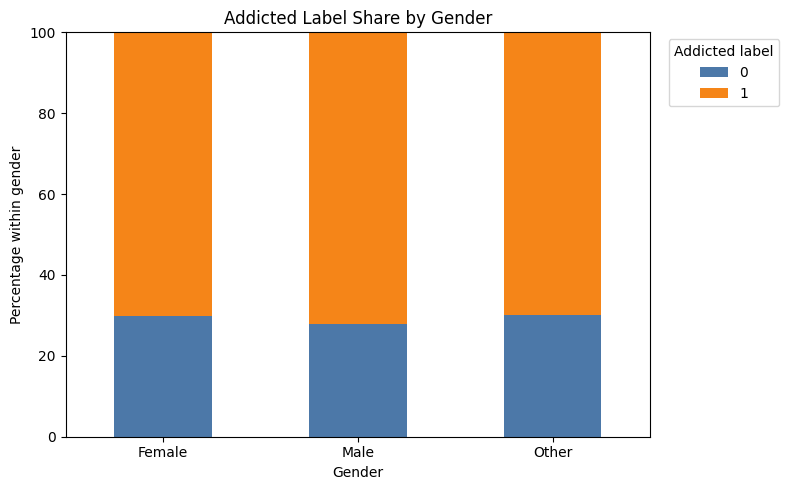

In [5]:
from scipy.stats import chi2_contingency

# Counts and row percentages show whether target rates differ by gender category.
gender_target_counts = pd.crosstab(df_prepared['gender'], df_prepared['addicted_label'])
gender_target_percentages = (
    pd.crosstab(df_prepared['gender'], df_prepared['addicted_label'], normalize='index')
    .mul(100)
    .round(2)
)

chi2, gender_chi2_p_value, gender_chi2_dof, gender_expected = chi2_contingency(gender_target_counts)
n = gender_target_counts.to_numpy().sum()
rows, cols = gender_target_counts.shape
gender_cramers_v = np.sqrt((chi2 / n) / min(rows - 1, cols - 1))

print('Gender vs addicted_label - counts')
display(gender_target_counts)

print('Gender vs addicted_label - row percentages')
display(gender_target_percentages)

print(f"Chi-square p-value: {gender_chi2_p_value:.4f}")
print(f"Cramer's V: {gender_cramers_v:.4f}")

# Normalized visualization: each gender sums to 100%, so the comparison is not distorted by group size.
gender_target_percentages.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    color=['#4C78A8', '#F58518']
)
plt.title('Addicted Label Share by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage within gender')
plt.legend(title='Addicted label', labels=['0', '1'], bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

### Gender Diagnostic Interpretation

The gender target rates are very close across categories, and the association size is very small. This supports excluding `gender` from the predictive feature matrix instead of imputing `Other` into `Male` or `Female`, or removing one-third of the dataset. Gender remains available for descriptive checks, but the model will focus on behavioral usage variables.

### Addiction Level Target-Proxy Check

`addiction_level` is useful for descriptive context, but it must be checked carefully before modeling. If its categories map directly to `addicted_label`, then it is not an independent predictor; it is an answer-key proxy. Missing addiction levels are shown as `Not recorded` for EDA only rather than imputed as a real severity category.

Addiction level display vs addicted_label - counts


addicted_label,0,1,All
addiction_level_display,,,
Mild,1373,0,1373
Moderate,0,2874,2874
Not recorded,819,0,819
Severe,0,2434,2434
All,2192,5308,7500


Addiction level display vs addicted_label - row percentages


addicted_label,0,1
addiction_level_display,,
Mild,100.0,0.0
Moderate,0.0,100.0
Not recorded,100.0,0.0
Severe,0.0,100.0


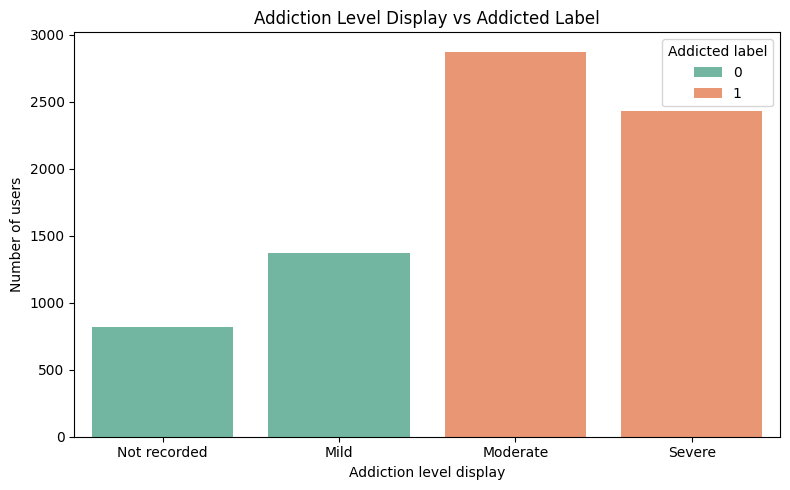

In [6]:
addiction_level_target_counts = pd.crosstab(
    df_prepared['addiction_level_display'],
    df_prepared['addicted_label'],
    margins=True
)

addiction_level_target_percentages = (
    pd.crosstab(
        df_prepared['addiction_level_display'],
        df_prepared['addicted_label'],
        normalize='index'
    )
    .mul(100)
    .round(2)
)

print('Addiction level display vs addicted_label - counts')
display(addiction_level_target_counts)

print('Addiction level display vs addicted_label - row percentages')
display(addiction_level_target_percentages)

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_prepared,
    x='addiction_level_display',
    hue='addicted_label',
    order=['Not recorded', 'Mild', 'Moderate', 'Severe'],
    palette='Set2'
)
plt.title('Addiction Level Display vs Addicted Label')
plt.xlabel('Addiction level display')
plt.ylabel('Number of users')
plt.legend(title='Addicted label')
plt.tight_layout()
plt.show()

### Addiction Level Diagnostic Interpretation

`addiction_level` behaves as a deterministic target proxy in this dataset: `Not recorded` and `Mild` align with `addicted_label = 0`, while `Moderate` and `Severe` align with `addicted_label = 1`. Therefore, `addiction_level` and its display version are excluded from predictive modeling to avoid leakage. Rows with missing `addiction_level` are kept because their behavioral features and `addicted_label` remain valid.

### Feature Preparation

The original cleaned columns are kept in `df_prepared` for EDA. New features are added to summarize usage behavior and create intensity measures. Ratio features safely handle division by zero by replacing invalid ratios with `0`.

Gender was checked against the target before modeling and showed weak association. Therefore `gender` is retained for descriptive EDA only and excluded from the model feature matrix. `addiction_level` is also excluded because it behaves as a deterministic target proxy.

In [7]:
# Simple engineered features
df_prepared['usage_component_total_hours'] = (
    df_prepared['social_media_hours']
    + df_prepared['gaming_hours']
    + df_prepared['work_study_hours']
)

screen_time_nonzero = df_prepared['daily_screen_time_hours'].replace(0, np.nan)

df_prepared['notifications_per_screen_hour'] = (
    df_prepared['notifications_per_day'] / screen_time_nonzero
).replace([np.inf, -np.inf], np.nan).fillna(0)

df_prepared['app_opens_per_screen_hour'] = (
    df_prepared['app_opens_per_day'] / screen_time_nonzero
).replace([np.inf, -np.inf], np.nan).fillna(0)

df_prepared['sleep_below_7_hours'] = (df_prepared['sleep_hours'] < 7).astype(int)

excluded_modeling_columns = [
    'transaction_id',
    'user_id',
    'addicted_label',
    'addiction_level',
    'addiction_level_display',
    'gender'
]

numeric_model_features = [
    'age',
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time',
    'usage_component_total_hours',
    'notifications_per_screen_hour',
    'app_opens_per_screen_hour',
    'sleep_below_7_hours'
]

categorical_model_features = ['stress_level', 'academic_work_impact']
model_feature_columns = numeric_model_features + categorical_model_features

# Keep an unencoded feature dataframe available for sklearn ColumnTransformer pipelines.
X_unencoded = df_prepared[model_feature_columns].copy()

# Create a fully numeric feature matrix for simple models.
X = pd.get_dummies(
    X_unencoded,
    columns=categorical_model_features,
    drop_first=False,
    dtype=int
)

y = df_prepared['addicted_label'].astype(int).copy()

print(f'df_prepared shape: {df_prepared.shape}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

print('\nExcluded modeling columns:')
print(excluded_modeling_columns)

print('\nRecommended unencoded feature columns for Person 4 pipeline option:')
print(model_feature_columns)

print('\nFinal numeric X columns:')
print(X.columns.tolist())

display(df_prepared.head())
display(X.head())
display(y.value_counts().sort_index().rename('target_count').to_frame())

df_prepared shape: (7500, 21)
X shape: (7500, 18)
y shape: (7500,)

Excluded modeling columns:
['transaction_id', 'user_id', 'addicted_label', 'addiction_level', 'addiction_level_display', 'gender']

Recommended unencoded feature columns for Person 4 pipeline option:
['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'usage_component_total_hours', 'notifications_per_screen_hour', 'app_opens_per_screen_hour', 'sleep_below_7_hours', 'stress_level', 'academic_work_impact']

Final numeric X columns:
['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'usage_component_total_hours', 'notifications_per_screen_hour', 'app_opens_per_screen_hour', 'sleep_below_7_hours', 'stress_level_High', 'stress_level_Low', 'stress_level_Medium', 'academic_work_i

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,...,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,addiction_level_display,usage_component_total_hours,notifications_per_screen_hour,app_opens_per_screen_hour,sleep_below_7_hours
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,...,3.95,Medium,Yes,NaN,0,Not recorded,7.45,76.780186,47.678019,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,...,6.71,Medium,Yes,NaN,0,Not recorded,10.49,24.950884,13.948919,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,...,8.68,High,No,Mild,0,Mild,7.54,7.260726,17.491749,1
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,...,9.77,High,Yes,Moderate,1,Moderate,10.90,22.733078,13.665390,0
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,...,12.55,Low,No,Severe,1,Severe,14.61,13.654618,17.771084,1


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,usage_component_total_hours,notifications_per_screen_hour,app_opens_per_screen_hour,sleep_below_7_hours,stress_level_High,stress_level_Low,stress_level_Medium,academic_work_impact_No,academic_work_impact_Yes
0,21,3.23,2.01,0.89,4.55,7.55,248,154,3.95,7.45,76.780186,47.678019,0,0,0,1,0,1
1,24,5.09,3.81,2.24,4.44,7.66,127,71,6.71,10.49,24.950884,13.948919,0,0,0,1,0,1
2,31,6.06,1.36,3.83,2.35,4.92,44,106,8.68,7.54,7.260726,17.491749,1,1,0,0,1,0
3,32,7.83,5.85,1.51,3.54,8.23,178,107,9.77,10.90,22.733078,13.665390,0,1,0,0,0,1
4,25,9.96,5.92,3.42,5.27,6.21,136,177,12.55,14.61,13.654618,17.771084,1,0,1,0,1,0


,target_count
addicted_label,
0,2192
1,5308


### Person 2 Handoff to Person 3 and Person 4

1. Preprocessing started from `df_clean`, which retained all observed gender categories instead of removing or imputing `Other`.
2. Missing `addiction_level` values were kept in the source column and shown as `Not recorded` in `addiction_level_display` for EDA only. This avoids treating missing values as a real severity category.
3. No target imputation was applied to `addicted_label`.
4. Gender was tested against `addicted_label` before modeling. Because the association was weak, `gender` is excluded from the model feature matrix and kept only for descriptive checks.
5. `addiction_level` was tested against `addicted_label` and behaves as a deterministic target proxy, so both `addiction_level` and `addiction_level_display` are excluded from modeling.
6. New features created: `usage_component_total_hours`, `notifications_per_screen_hour`, `app_opens_per_screen_hour`, and `sleep_below_7_hours`.
7. `df_prepared` is ready for Person 3. `X`, `X_unencoded`, `y`, `model_feature_columns`, and `excluded_modeling_columns` are ready for Person 4.

## 3. Descriptive Analytics and EDA - Person 3

This section uses `df_prepared` from Person 2 to summarize the cleaned and preprocessed dataset. The goal is to understand the target distribution, compare usage patterns across important groups, and identify variables that may be useful for predictive modeling.

The analysis keeps `addiction_level` for descriptive EDA only. It is not a modeling feature because it closely tracks `addicted_label` and would leak target information into the predictive model.

In [8]:
# Phase 3 setup: key columns for descriptive analytics and EDA
eda_numeric_columns = [
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time'
]

eda_categorical_columns = [
    'gender',
    'stress_level',
    'academic_work_impact',
    'addiction_level_display',
    'addicted_label'
]

print(f'Prepared dataset rows: {df_prepared.shape[0]}')
print(f'Prepared dataset columns: {df_prepared.shape[1]}')

print()
print('Summary statistics for numeric usage columns:')
display(df_prepared[eda_numeric_columns].describe().round(2))

print()
print('Categorical value counts:')
for col in eda_categorical_columns:
    print()
    print(col)
    display(df_prepared[col].value_counts(dropna=False).rename('count').to_frame())

print()
print('Target distribution with percentages:')
target_distribution = pd.concat(
    [
        df_prepared['addicted_label'].value_counts().sort_index().rename('count'),
        (df_prepared['addicted_label'].value_counts(normalize=True).sort_index() * 100).round(2).rename('percentage')
    ],
    axis=1
)
display(target_distribution)


Prepared dataset rows: 7500
Prepared dataset columns: 21

Summary statistics for numeric usage columns:


,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
count,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00
mean,7.50,3.27,2.01,3.24,6.74,134.26,97.83,9.24
std,2.61,1.59,1.15,1.60,1.28,66.59,48.42,2.72
min,3.00,0.50,0.00,0.50,4.50,20.00,15.00,3.58
25%,5.22,1.91,1.02,1.85,5.63,76.00,55.00,6.96
50%,7.52,3.27,2.04,3.23,6.72,134.00,98.00,9.26
75%,9.81,4.63,2.99,4.64,7.84,191.00,140.00,11.54
max,12.00,6.00,4.00,6.00,9.00,250.00,180.00,14.88



Categorical value counts:

gender


,count
gender,
Male,2553
Other,2486
Female,2461



stress_level


...

,count
addiction_level_display,
Moderate,2874
Severe,2434
Mild,1373
Not recorded,819



addicted_label


,count
addicted_label,
1,5308
0,2192



Target distribution with percentages:


,count,percentage
addicted_label,,
0,2192,29.23
1,5308,70.77


### Initial Descriptive Observations

The prepared dataset contains all 7,500 rows because the `Other` gender category was retained rather than imputed or removed. The target variable is imbalanced: `addicted_label = 1` has 5,308 rows, about 70.77% of the prepared dataset, while `addicted_label = 0` has 2,192 rows, about 29.23%.

The categorical variables are still useful for EDA. `gender`, `stress_level`, and `academic_work_impact` are fairly balanced, while `addiction_level_display` includes `Not recorded` values for missing addiction levels so those rows can stay in descriptive analysis.

In [9]:
# Average usage values by key groups
print('Average usage values by addicted_label:')
avg_by_addicted_label = df_prepared.groupby('addicted_label')[eda_numeric_columns].mean().round(2)
display(avg_by_addicted_label)

print('Average usage values by gender:')
avg_by_gender = df_prepared.groupby('gender')[eda_numeric_columns].mean().round(2)
display(avg_by_gender)

print('Average usage values by stress_level:')
avg_by_stress = df_prepared.groupby('stress_level')[eda_numeric_columns].mean().round(2)
display(avg_by_stress)

print('Average usage values by academic_work_impact:')
avg_by_impact = df_prepared.groupby('academic_work_impact')[eda_numeric_columns].mean().round(2)
display(avg_by_impact)

print('Median usage values by addicted_label, included to reduce the effect of extreme values:')
median_by_addicted_label = df_prepared.groupby('addicted_label')[eda_numeric_columns].median().round(2)
display(median_by_addicted_label)


Average usage values by addicted_label:


,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
addicted_label,,,,,,,,
0,5.16,2.25,2.00,3.24,6.67,134.33,97.00,6.89
1,8.47,3.70,2.02,3.24,6.77,134.23,98.18,10.21


Average usage values by gender:


,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
gender,,,,,,,,
Female,7.45,3.26,2.02,3.27,6.75,133.30,98.44,9.19
Male,7.56,3.30,2.01,3.21,6.79,135.50,97.39,9.32
Other,7.49,3.26,2.01,3.25,6.67,133.92,97.68,9.23


Average usage values by stress_level:


,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
stress_level,,,,,,,,
High,7.58,3.25,2.01,3.30,6.70,133.87,97.28,9.33
Low,7.50,3.29,2.01,3.23,6.76,134.18,97.54,9.25
Medium,7.42,3.29,2.02,3.19,6.76,134.74,98.71,9.15


Average usage values by academic_work_impact:


,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
academic_work_impact,,,,,,,,
No,7.51,3.26,2.02,3.28,6.75,133.90,98.19,9.26
Yes,7.49,3.28,2.01,3.21,6.73,134.62,97.47,9.23


Median usage values by addicted_label, included to reduce the effect of extreme values:


,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
addicted_label,,,,,,,,
0,5.06,2.28,1.99,3.22,6.66,136.0,97.0,6.79
1,8.84,4.06,2.05,3.23,6.76,134.0,99.0,10.58


In [10]:
# Normalized categorical comparisons with addicted_label
# Percentages make it easier to compare category relationships when category sizes differ.
categorical_relationship_columns = [
    'stress_level',
    'academic_work_impact',
    'gender',
    'addiction_level_display'
]

for col in categorical_relationship_columns:
    print(f'{col} vs addicted_label - counts')
    counts_table = pd.crosstab(df_prepared[col], df_prepared['addicted_label'])
    display(counts_table)

    print(f'{col} vs addicted_label - row percentages')
    percentage_table = (
        pd.crosstab(df_prepared[col], df_prepared['addicted_label'], normalize='index')
        .mul(100)
        .round(2)
    )
    display(percentage_table)
    print()


stress_level vs addicted_label - counts


addicted_label,0,1
stress_level,,
High,759,1801
Low,721,1782
Medium,712,1725


stress_level vs addicted_label - row percentages


addicted_label,0,1
stress_level,,
High,29.65,70.35
Low,28.81,71.19
Medium,29.22,70.78



academic_work_impact vs addicted_label - counts


...

addicted_label,0,1
gender,,
Female,29.78,70.22
Male,27.77,72.23
Other,30.17,69.83



addiction_level_display vs addicted_label - counts


addicted_label,0,1
addiction_level_display,,
Mild,1373,0
Moderate,0,2874
Not recorded,819,0
Severe,0,2434


addiction_level_display vs addicted_label - row percentages


addicted_label,0,1
addiction_level_display,,
Mild,100.0,0.0
Moderate,0.0,100.0
Not recorded,100.0,0.0
Severe,0.0,100.0


### Categorical Relationship Observations

The normalized category tables support the visual interpretation. `stress_level`, `academic_work_impact`, and `gender` have similar addicted-label percentages across their categories, so they do not show strong descriptive separation in this dataset.

`addiction_level_display` is different: `Mild` and `Not recorded` align with `addicted_label = 0`, while `Moderate` and `Severe` align with `addicted_label = 1`. This makes `addiction_level` useful for explaining the label definition descriptively, but it should remain excluded from predictive modeling because it behaves like a target proxy.

### Grouped Summary Observations

The clearest differences are between `addicted_label` groups. Users with `addicted_label = 1` average about 8.47 daily screen-time hours, 10.21 weekend screen-time hours, and 3.72 social-media hours. Users with `addicted_label = 0` average about 5.16 daily screen-time hours, 6.89 weekend screen-time hours, and 2.28 social-media hours.

Gaming hours, work/study hours, sleep hours, notifications per day, and app opens per day are much closer between the two target groups. Average usage values by `gender`, `stress_level`, and `academic_work_impact` are also similar, so these variables look less separated than screen-time-related variables in the descriptive summaries.

### Numeric Range and Outlier Check

Before relying on the distribution charts, check numeric ranges and simple IQR bounds. This is not a reason to automatically remove rows; it is a sanity check for impossible values or extreme points that could distort the EDA or model.

In [11]:
range_check_rows = []
for col in eda_numeric_columns:
    q1 = df_prepared[col].quantile(0.25)
    q3 = df_prepared[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outside_iqr = ((df_prepared[col] < lower_bound) | (df_prepared[col] > upper_bound)).sum()
    range_check_rows.append({
        'column': col,
        'min': df_prepared[col].min(),
        'q1': q1,
        'median': df_prepared[col].median(),
        'q3': q3,
        'max': df_prepared[col].max(),
        'iqr': iqr,
        'iqr_lower_bound': lower_bound,
        'iqr_upper_bound': upper_bound,
        'outside_iqr_count': outside_iqr
    })

range_check_df = pd.DataFrame(range_check_rows)
display(range_check_df.round(2))

,column,min,q1,median,q3,max,iqr,iqr_lower_bound,iqr_upper_bound,outside_iqr_count
0,daily_screen_time_hours,3.00,5.22,7.52,9.81,12.00,4.59,-1.67,16.70,0
1,social_media_hours,0.50,1.91,3.27,4.63,6.00,2.72,-2.17,8.71,0
2,gaming_hours,0.00,1.02,2.04,2.99,4.00,1.97,-1.94,5.94,0
3,work_study_hours,0.50,1.85,3.23,4.64,6.00,2.79,-2.33,8.82,0
4,sleep_hours,4.50,5.63,6.72,7.84,9.00,2.21,2.32,11.16,0
5,notifications_per_day,20.00,76.00,134.00,191.00,250.00,115.00,-96.50,363.50,0
6,app_opens_per_day,15.00,55.00,98.00,140.00,180.00,85.00,-72.50,267.50,0
7,weekend_screen_time,3.58,6.96,9.26,11.54,14.88,4.58,0.09,18.41,0


### Numeric Range Check Interpretation

The numeric values stay within plausible simulated ranges, and the IQR check does not suggest a need to remove records. Any IQR-flagged values should be treated as distribution tails unless they violate a known data rule. This supports keeping the full dataset for modeling.

### EDA Charts

These charts focus on whether the prepared data shows visible differences between users labeled as addicted and non-addicted. The main things to check are target imbalance, whether screen-time-related variables separate the two target groups, whether sleep and notification behavior look different, and whether categorical variables such as stress level, academic/work impact, and gender show clear patterns with `addicted_label`.


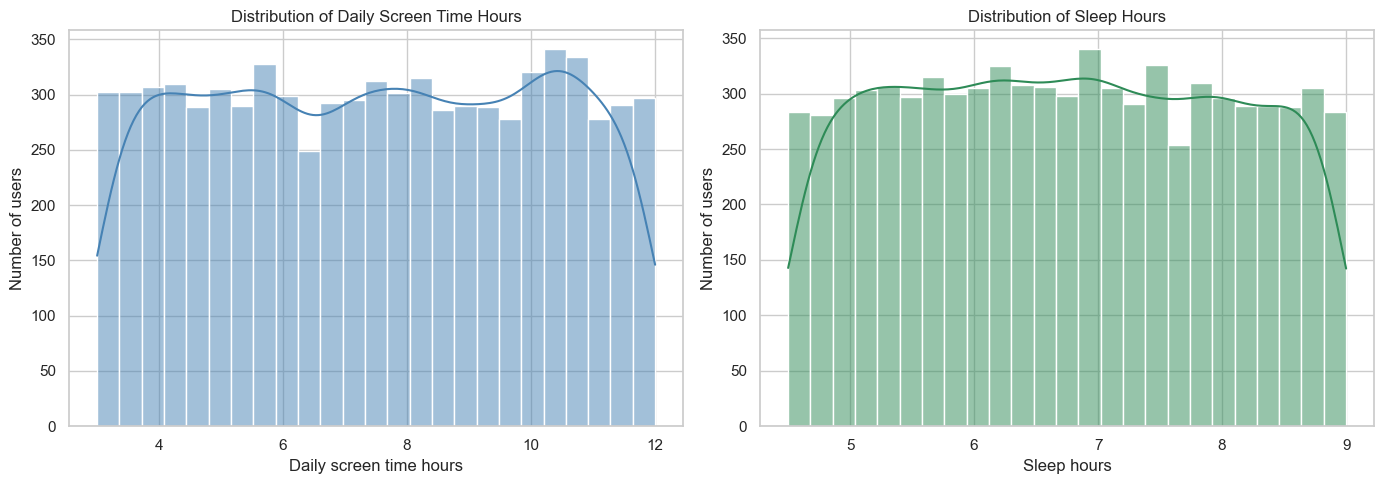

In [12]:
# Distribution charts for daily screen time and sleep hours
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df_prepared,
    x='daily_screen_time_hours',
    bins=25,
    kde=True,
    ax=axes[0],
    color='steelblue'
)
axes[0].set_title('Distribution of Daily Screen Time Hours')
axes[0].set_xlabel('Daily screen time hours')
axes[0].set_ylabel('Number of users')

sns.histplot(
    data=df_prepared,
    x='sleep_hours',
    bins=25,
    kde=True,
    ax=axes[1],
    color='seagreen'
)
axes[1].set_title('Distribution of Sleep Hours')
axes[1].set_xlabel('Sleep hours')
axes[1].set_ylabel('Number of users')

plt.tight_layout()
plt.show()


### Distribution Chart Observations

Daily screen time ranges from about 3.00 to 11.99 hours, while sleep hours range from about 4.50 to 9.00 hours. These ungrouped distributions show the overall spread of the variables; the target-group separation is assessed in the comparison charts and grouped summaries below.

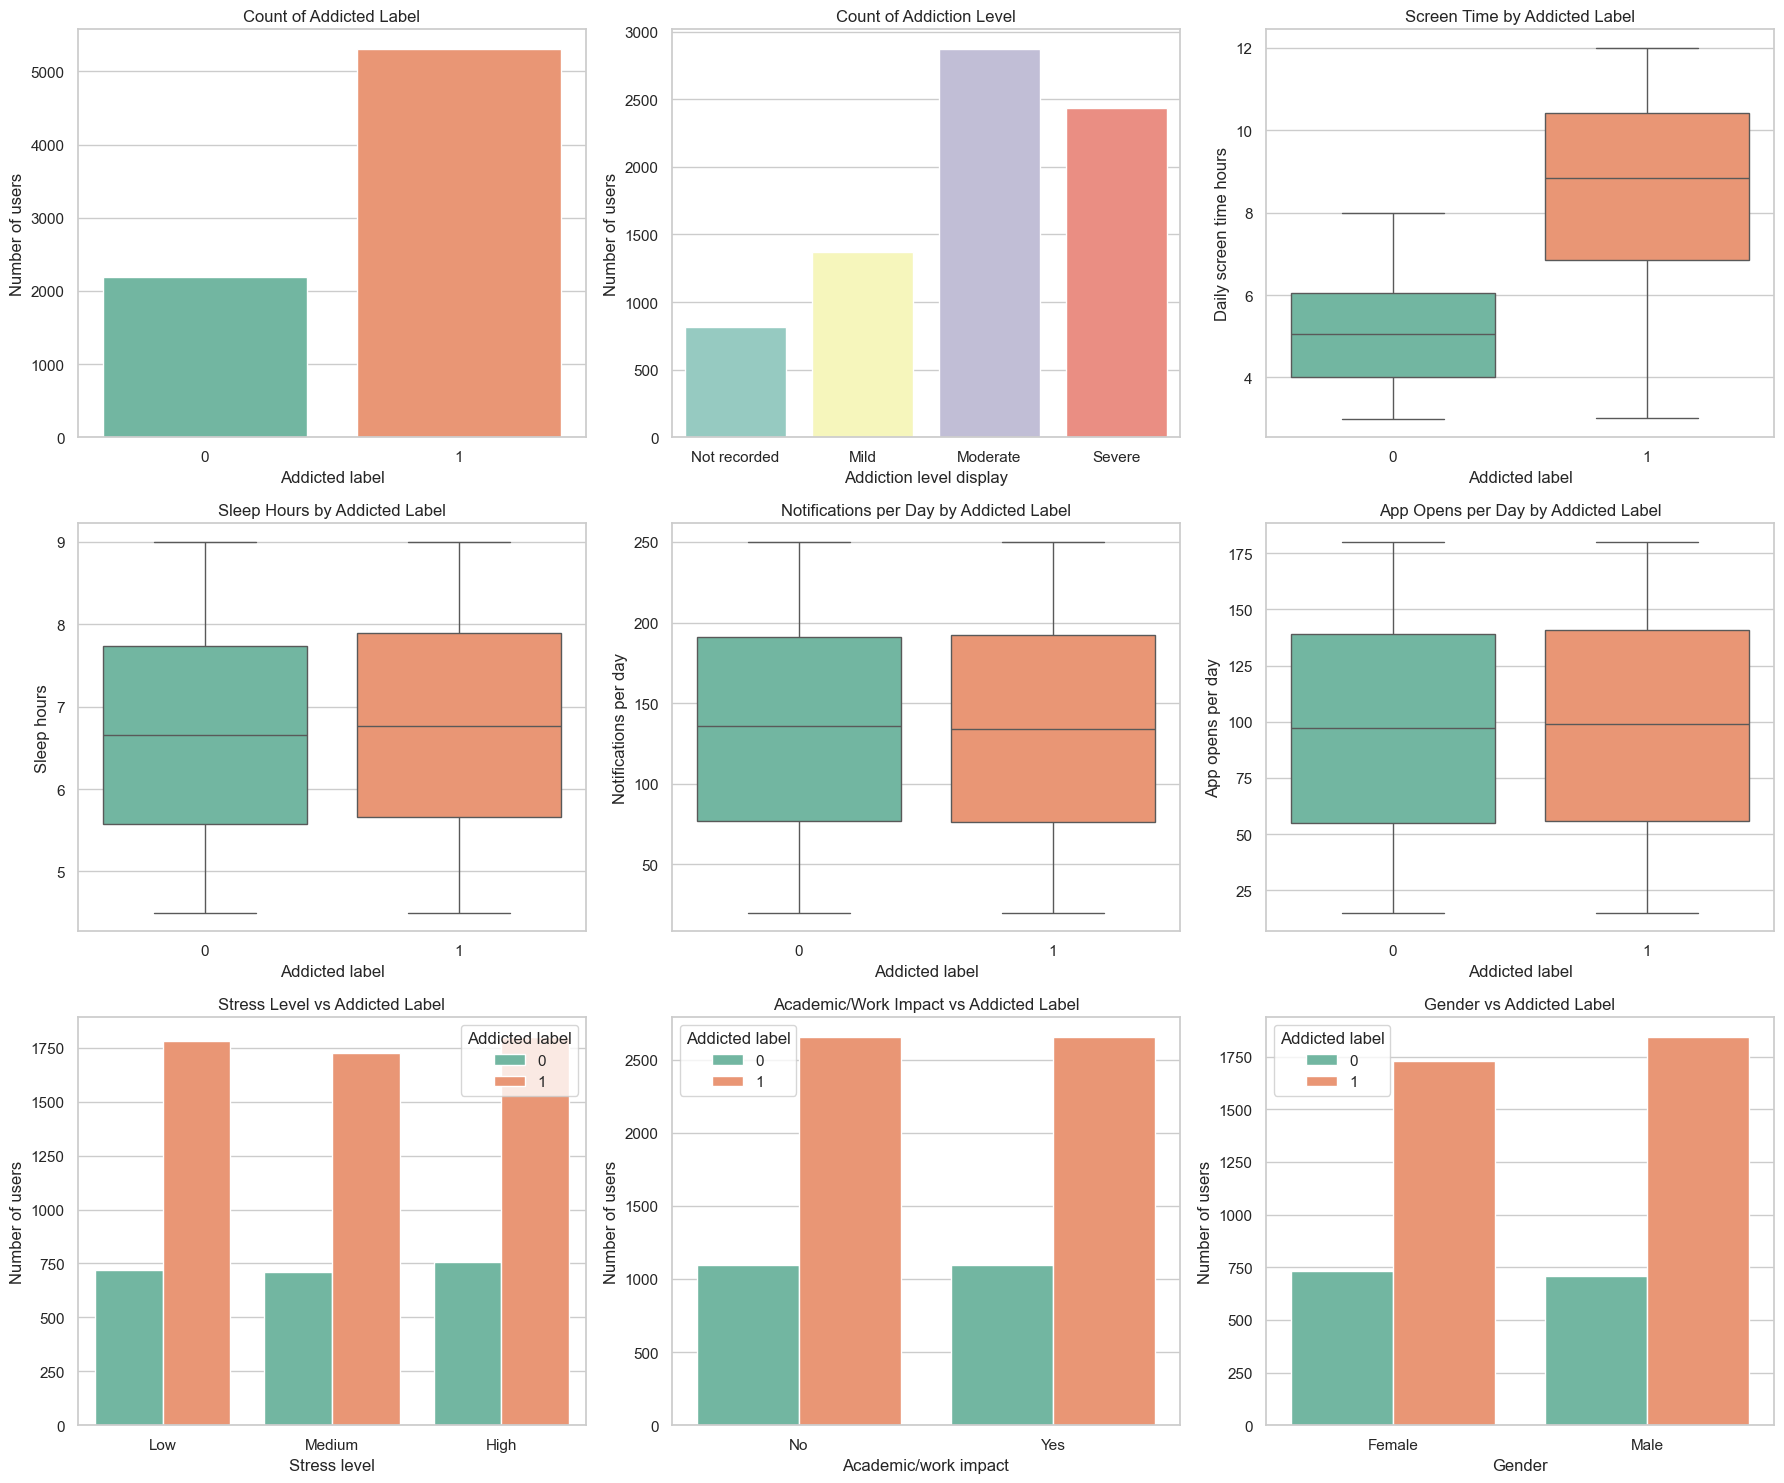

In [13]:
# Count charts and comparison charts by addicted_label
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

sns.countplot(data=df_prepared, x='addicted_label', ax=axes[0], palette='Set2', hue='addicted_label', legend=False)
axes[0].set_title('Count of Addicted Label')
axes[0].set_xlabel('Addicted label')
axes[0].set_ylabel('Number of users')

sns.countplot(data=df_prepared, x='addiction_level_display', ax=axes[1], order=['Not recorded', 'Mild', 'Moderate', 'Severe'], palette='Set3', hue='addiction_level_display', legend=False)
axes[1].set_title('Count of Addiction Level')
axes[1].set_xlabel('Addiction level display')
axes[1].set_ylabel('Number of users')

sns.boxplot(data=df_prepared, x='addicted_label', y='daily_screen_time_hours', ax=axes[2], palette='Set2', hue='addicted_label', legend=False)
axes[2].set_title('Screen Time by Addicted Label')
axes[2].set_xlabel('Addicted label')
axes[2].set_ylabel('Daily screen time hours')

sns.boxplot(data=df_prepared, x='addicted_label', y='sleep_hours', ax=axes[3], palette='Set2', hue='addicted_label', legend=False)
axes[3].set_title('Sleep Hours by Addicted Label')
axes[3].set_xlabel('Addicted label')
axes[3].set_ylabel('Sleep hours')

sns.boxplot(data=df_prepared, x='addicted_label', y='notifications_per_day', ax=axes[4], palette='Set2', hue='addicted_label', legend=False)
axes[4].set_title('Notifications per Day by Addicted Label')
axes[4].set_xlabel('Addicted label')
axes[4].set_ylabel('Notifications per day')

sns.boxplot(data=df_prepared, x='addicted_label', y='app_opens_per_day', ax=axes[5], palette='Set2', hue='addicted_label', legend=False)
axes[5].set_title('App Opens per Day by Addicted Label')
axes[5].set_xlabel('Addicted label')
axes[5].set_ylabel('App opens per day')

sns.countplot(data=df_prepared, x='stress_level', hue='addicted_label', ax=axes[6], order=['Low', 'Medium', 'High'], palette='Set2')
axes[6].set_title('Stress Level vs Addicted Label')
axes[6].set_xlabel('Stress level')
axes[6].set_ylabel('Number of users')
axes[6].legend(title='Addicted label')

sns.countplot(data=df_prepared, x='academic_work_impact', hue='addicted_label', ax=axes[7], order=['No', 'Yes'], palette='Set2')
axes[7].set_title('Academic/Work Impact vs Addicted Label')
axes[7].set_xlabel('Academic/work impact')
axes[7].set_ylabel('Number of users')
axes[7].legend(title='Addicted label')

sns.countplot(data=df_prepared, x='gender', hue='addicted_label', ax=axes[8], order=['Female', 'Male'], palette='Set2')
axes[8].set_title('Gender vs Addicted Label')
axes[8].set_xlabel('Gender')
axes[8].set_ylabel('Number of users')
axes[8].legend(title='Addicted label')

plt.tight_layout()
plt.show()


### Comparison Chart Observations

The count chart confirms that `addicted_label = 1` is the majority class. The boxplots show clearer separation for daily screen time than for sleep hours, notifications, or app opens. The categorical count charts for stress level, academic/work impact, and gender do not show strong visible separation across the two target labels. The earlier normalized gender chart is the better visual for comparing gender target rates because each gender category is scaled to 100%.

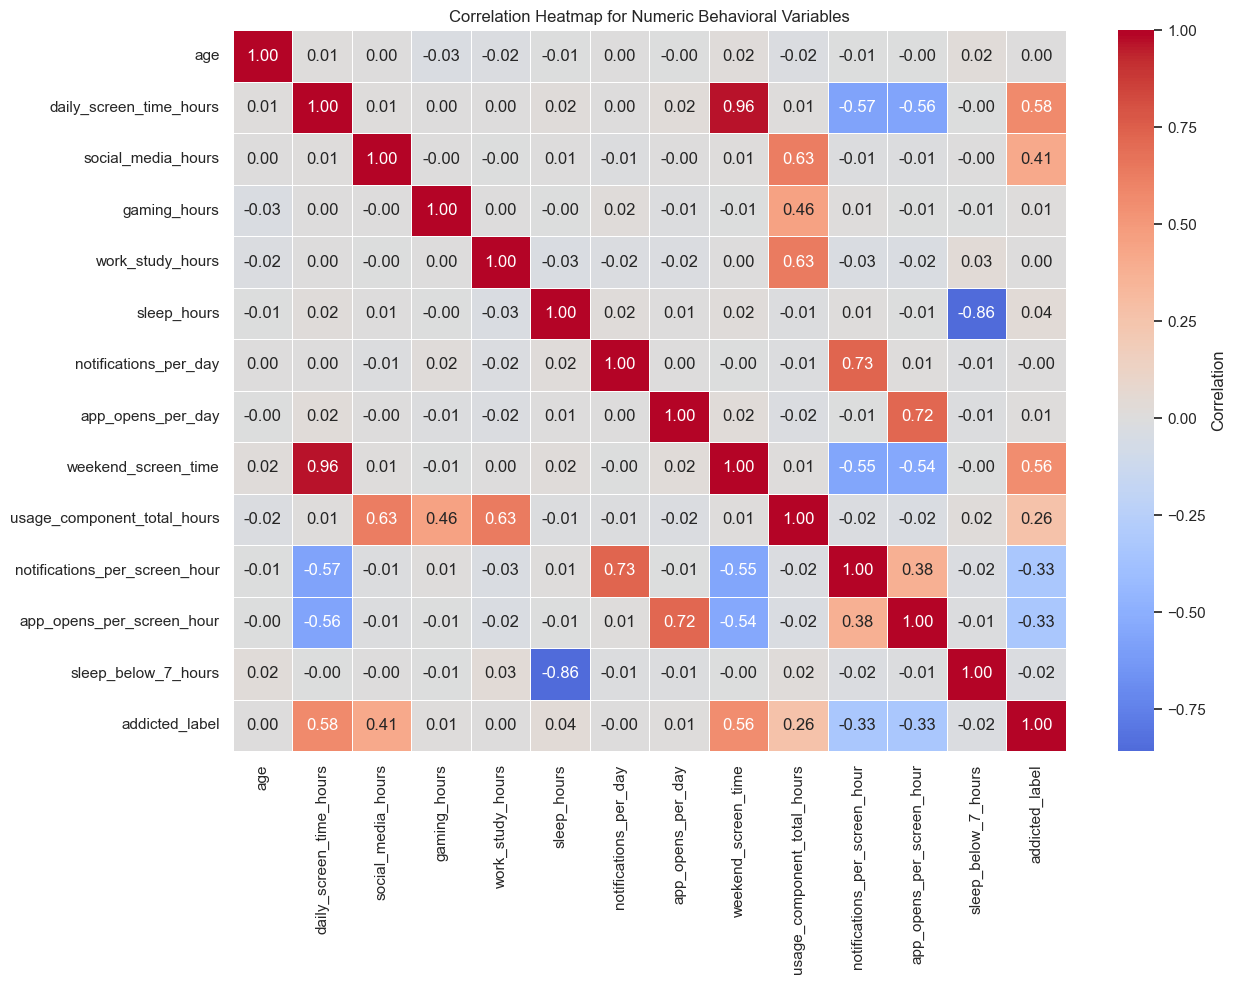

Correlation with addicted_label, sorted by absolute strength:


,correlation_with_addicted_label
daily_screen_time_hours,0.577
weekend_screen_time,0.555
social_media_hours,0.414
notifications_per_screen_hour,-0.329
app_opens_per_screen_hour,-0.329
usage_component_total_hours,0.264
sleep_hours,0.035
sleep_below_7_hours,-0.022
app_opens_per_day,0.011
gaming_hours,0.008


In [14]:
# Correlation heatmap for numeric variables
correlation_columns = [
    'age',
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time',
    'usage_component_total_hours',
    'notifications_per_screen_hour',
    'app_opens_per_screen_hour',
    'sleep_below_7_hours',
    'addicted_label'
]

correlation_matrix = df_prepared[correlation_columns].corr(numeric_only=True)

plt.figure(figsize=(13, 10))
sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)
plt.title('Correlation Heatmap for Numeric Behavioral Variables')
plt.tight_layout()
plt.show()

print('Correlation with addicted_label, sorted by absolute strength:')
correlation_with_target = (
    correlation_matrix['addicted_label']
    .drop('addicted_label')
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .round(3)
)
display(correlation_with_target.rename('correlation_with_addicted_label').to_frame())

### Correlation Heatmap Observations

The strongest numeric relationships with `addicted_label` are `daily_screen_time_hours` (about 0.577), `weekend_screen_time` (about 0.555), and `social_media_hours` (about 0.414). The engineered ratio features also show moderate negative correlations, but they use daily screen time as the denominator, so Person 4 should treat them as derived screen-time-intensity features rather than independent evidence.

Gender was assessed separately as a categorical variable using target rates, Cramer's V, and a normalized chart. It is not included in this numeric correlation heatmap or in the predictive model.

Correlation does not prove causation, but it helps identify non-leaking variables that may be useful for classification models.

### Phase 3 Questions Answered

1. The target variable is imbalanced. About 70.77% of the prepared rows have `addicted_label = 1`, while about 29.23% have `addicted_label = 0`.
2. Addicted and non-addicted groups appear different in screen time. The `addicted_label = 1` group has higher average daily screen time (8.47 vs 5.16 hours) and weekend screen time (10.21 vs 6.89 hours).
3. Addicted and non-addicted groups do not appear very different in sleep hours. The averages and medians are close, so sleep hours may be weaker by itself for modeling in this dataset.
4. `stress_level`, `academic_work_impact`, and `gender` do not show strong separation with `addicted_label` in the grouped summaries, row percentages, or charts. Gender is therefore excluded from modeling after the diagnostic check.
5. The variables that seem most useful for modeling are `daily_screen_time_hours`, `weekend_screen_time`, `social_media_hours`, and possibly the engineered usage-intensity features. `addiction_level` should not be used for prediction because it behaves like a target proxy.

### Person 3 Handoff to Person 4

1. Main EDA observations: `addicted_label = 1` is the majority class; daily screen time, weekend screen time, and social media hours are higher for the `addicted_label = 1` group; sleep hours, notifications, app opens, gender, stress level, and academic/work impact show weaker differences in the descriptive summaries.
2. Possible outliers: the checked numeric columns do not show obvious extreme outlier problems from the distribution charts. Values appear within reasonable simulated ranges, but model performance should still be evaluated carefully.
3. Target balance: the target is imbalanced, with about 70.77% labeled `1` and 29.23% labeled `0`. Person 4 should use `stratify=y` during the train/test split and compare models against a majority-class baseline.
4. Features that seem important from EDA: `daily_screen_time_hours`, `weekend_screen_time`, `social_media_hours`, `usage_component_total_hours`, `notifications_per_screen_hour`, and `app_opens_per_screen_hour` may be useful. The ratio features should be interpreted carefully because they are derived from daily screen time.
5. Gender decision: gender showed weak target separation and is excluded from the predictive model. This keeps all rows without imputing or forcing `Other` into a binary encoding.
6. Leakage warning: `addiction_level` should not be used in the predictive model. In this prepared dataset it behaves like a target proxy, with `Mild` and `Not recorded` aligned to `addicted_label = 0` and `Moderate` and `Severe` aligned to `addicted_label = 1`.
7. `df_prepared`, `X`, `X_unencoded`, `y`, and `model_feature_columns` are ready for Phase 4 predictive analytics.

## 4. Predictive Analytics - Person 4

This section builds simple classification models to predict `addicted_label` using the non-leaking feature set prepared by Person 2. The main goal is to compare several course-appropriate models, choose one suitable model, tune only that selected model, and interpret the results clearly.

Important leakage rule: `transaction_id`, `user_id`, `gender`, `addiction_level`, and `addicted_label` are not used as input features. `addiction_level` is excluded because Person 3 showed that it behaves like a target proxy.

### Modeling Setup and Leakage Check

The train/test split uses 80% training data and 20% testing data with `random_state=42`. Because the target is imbalanced, the split uses `stratify=y` so the class proportions stay similar in both sets.

In [15]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    make_scorer
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Confirm the modeling feature matrix follows the project leakage and gender-exclusion rules.
leakage_columns = ['transaction_id', 'user_id', 'gender', 'addiction_level', 'addiction_level_display', 'addicted_label']
leakage_columns_in_X = [col for col in leakage_columns if col in X.columns]

print('Excluded/leakage columns found in X:')
print(leakage_columns_in_X if leakage_columns_in_X else 'None')

print()
print('Feature matrix and target shape:')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

print()
print('Target class balance before split:')
target_balance = pd.concat(
    [
        y.value_counts().sort_index().rename('count'),
        (y.value_counts(normalize=True).sort_index() * 100).round(2).rename('percentage')
    ],
    axis=1
)
display(target_balance)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print()
print('Train/test shapes:')
print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test: {y_test.shape}')

print()
print('Target balance in test set:')
test_balance = pd.concat(
    [
        y_test.value_counts().sort_index().rename('count'),
        (y_test.value_counts(normalize=True).sort_index() * 100).round(2).rename('percentage')
    ],
    axis=1
)
display(test_balance)

Excluded/leakage columns found in X:
None

Feature matrix and target shape:
X shape: (7500, 18)
y shape: (7500,)

Target class balance before split:


,count,percentage
addicted_label,,
0,2192,29.23
1,5308,70.77



Train/test shapes:
X_train: (6000, 18)
X_test: (1500, 18)
y_train: (6000,)
y_test: (1500,)

Target balance in test set:


,count,percentage
addicted_label,,
0,438,29.2
1,1062,70.8


### Baseline and First-Pass Model Comparison

A majority-class baseline is included so the classification models must beat a simple rule that always predicts the most common class. Logistic regression, decision tree, Naive Bayes, KNN, and a small neural network are then compared using the same train/test split.

In [16]:
def evaluate_classifier(model_name, fitted_model, X_eval, y_eval):
    predictions = fitted_model.predict(X_eval)
    tn, fp, fn, tp = confusion_matrix(y_eval, predictions).ravel()
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_eval, predictions),
        'balanced_accuracy': balanced_accuracy_score(y_eval, predictions),
        'precision_1': precision_score(y_eval, predictions, zero_division=0),
        'recall_1': recall_score(y_eval, predictions, zero_division=0),
        'recall_0': recall_score(y_eval, predictions, pos_label=0, zero_division=0),
        'f1_1': f1_score(y_eval, predictions, zero_division=0),
        'macro_f1': f1_score(y_eval, predictions, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_eval, predictions, average='weighted', zero_division=0),
        'true_negative': tn,
        'false_positive': fp,
        'false_negative': fn,
        'true_positive': tp
    }

candidate_models = {
    'Majority class baseline': DummyClassifier(strategy='most_frequent'),
    'Logistic regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Decision tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=7))
    ]),
    'Neural network': Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(
            hidden_layer_sizes=(32,),
            max_iter=1000,
            random_state=42,
            early_stopping=True
        ))
    ])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scoring = {
    'f1_1': 'f1',
    'macro_f1': 'f1_macro',
    'balanced_accuracy': 'balanced_accuracy',
    'recall_0': make_scorer(recall_score, pos_label=0, zero_division=0),
    'recall_1': make_scorer(recall_score, pos_label=1, zero_division=0)
}

cv_results = []
for model_name, model in candidate_models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=cv_scoring, n_jobs=None)
    cv_results.append({
        'model': model_name,
        'cv_f1_1_mean': scores['test_f1_1'].mean(),
        'cv_f1_1_std': scores['test_f1_1'].std(),
        'cv_macro_f1_mean': scores['test_macro_f1'].mean(),
        'cv_balanced_accuracy_mean': scores['test_balanced_accuracy'].mean(),
        'cv_recall_0_mean': scores['test_recall_0'].mean(),
        'cv_recall_1_mean': scores['test_recall_1'].mean()
    })

cv_model_results_df = (
    pd.DataFrame(cv_results)
    .sort_values(by='cv_f1_1_mean', ascending=False)
    .reset_index(drop=True)
)

print('Training-only cross-validation model comparison:')
display(cv_model_results_df.round(4))

selected_model_name = cv_model_results_df.loc[0, 'model']
print(f'Selected model family from training-only CV: {selected_model_name}')

model_results = []
fitted_candidate_models = {}

for model_name, model in candidate_models.items():
    model.fit(X_train, y_train)
    fitted_candidate_models[model_name] = model
    model_results.append(evaluate_classifier(model_name, model, X_test, y_test))

model_results_df = (
    pd.DataFrame(model_results)
    .sort_values(by='f1_1', ascending=False)
    .reset_index(drop=True)
)

print('Held-out test performance after model family selection:')
display(model_results_df.round(4))

Training-only cross-validation model comparison:


,model,cv_f1_1_mean,cv_f1_1_std,cv_macro_f1_mean,cv_balanced_accuracy_mean,cv_recall_0_mean,cv_recall_1_mean
0,Decision tree,0.9535,0.0046,0.9208,0.9218,0.8917,0.9520
1,Neural network,0.9366,0.0111,0.8888,0.8838,0.8221,0.9454
2,Logistic regression,0.9292,0.0066,0.8755,0.8697,0.7999,0.9395
3,KNN,0.9165,0.0078,0.8490,0.8383,0.7400,0.9366
4,Naive Bayes,0.9042,0.0053,0.8411,0.8476,0.8027,0.8924
5,Majority class baseline,0.8288,0.0002,0.4144,0.5000,0.0000,1.0000


Selected model family from training-only CV: Decision tree


Held-out test performance after model family selection:


,model,accuracy,balanced_accuracy,precision_1,recall_1,recall_0,f1_1,macro_f1,weighted_f1,true_negative,false_positive,false_negative,true_positive
0,Decision tree,0.9327,0.9203,0.9546,0.9501,0.8904,0.9523,0.9188,0.9328,390,48,53,1009
1,Neural network,0.9147,0.8854,0.9261,0.9557,0.8151,0.9407,0.8943,0.9136,357,81,47,1015
2,Logistic regression,0.9013,0.8773,0.9263,0.9350,0.8196,0.9306,0.8799,0.9010,359,79,69,993
3,KNN,0.8693,0.8266,0.8908,0.9294,0.7237,0.9097,0.8368,0.8671,317,121,75,987
4,Naive Bayes,0.8653,0.8459,0.9151,0.8927,0.7991,0.9037,0.8399,0.8664,350,88,114,948
5,Majority class baseline,0.7080,0.5000,0.7080,1.0000,0.0000,0.8290,0.4145,0.5870,0,438,0,1062


### First-Pass Model Interpretation

Model family selection is now based on 5-fold cross-validation inside the training data, not the held-out test set. The decision tree has the strongest training-only cross-validation F1-score and remains a good fit for the assignment because it is both high-performing and explainable.

The held-out test table is kept as a reporting check after model-family selection. Gender is not part of any candidate model. The earlier gender diagnostic showed weak association with `addicted_label`, so excluding it keeps the full dataset while avoiding unnecessary demographic features.

### Tune the Selected Model

Only the selected decision tree is tuned. The grid search uses 5-fold cross-validation on the training data and optimizes F1-score because the target is imbalanced. The held-out test set is used only after tuning to estimate final performance.

Best decision tree parameters:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 20}
Best cross-validation F1-score: 0.9549


,model,accuracy,balanced_accuracy,precision_1,recall_1,recall_0,f1_1,macro_f1,weighted_f1,true_negative,false_positive,false_negative,true_positive
0,Tuned decision tree,0.9313,0.9052,0.9371,0.968,0.8425,0.9523,0.9149,0.9305,369,69,34,1028


Classification report for tuned decision tree:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88       438
           1       0.94      0.97      0.95      1062

    accuracy                           0.93      1500
   macro avg       0.93      0.91      0.91      1500
weighted avg       0.93      0.93      0.93      1500



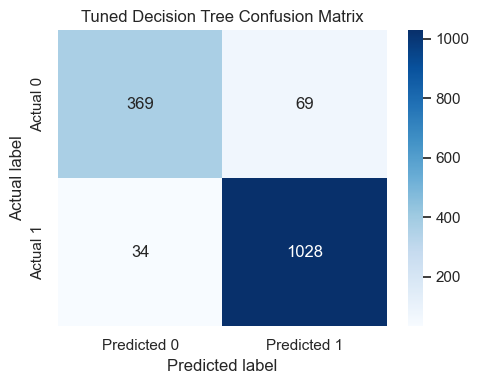

In [17]:
decision_tree_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_leaf': [1, 5, 10, 20]
}

decision_tree_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=decision_tree_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=None
)

decision_tree_grid.fit(X_train, y_train)

best_tree_model = decision_tree_grid.best_estimator_
best_tree_predictions = best_tree_model.predict(X_test)

print('Best decision tree parameters:')
print(decision_tree_grid.best_params_)
print(f"Best cross-validation F1-score: {decision_tree_grid.best_score_:.4f}")

final_tree_metrics = evaluate_classifier(
    'Tuned decision tree',
    best_tree_model,
    X_test,
    y_test
)

display(pd.DataFrame([final_tree_metrics]).round(4))

print('Classification report for tuned decision tree:')
print(classification_report(y_test, best_tree_predictions, zero_division=0))

final_confusion_matrix = confusion_matrix(y_test, best_tree_predictions)
plt.figure(figsize=(5, 4))
sns.heatmap(
    final_confusion_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
plt.title('Tuned Decision Tree Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.tight_layout()
plt.show()


### Engineered Feature Sensitivity Check

Because `usage_component_total_hours` and the ratio features are derived from other usage variables, run a sensitivity model without those engineered aggregate/intensity features. If the simpler model performs similarly or better, it is easier to defend as the final model because it depends less on questionable feature engineering.

In [18]:
sensitivity_excluded_features = [
    'usage_component_total_hours',
    'notifications_per_screen_hour',
    'app_opens_per_screen_hour'
]

sensitivity_feature_columns = [
    col for col in model_feature_columns
    if col not in sensitivity_excluded_features
]

X_sensitivity_unencoded = df_prepared[sensitivity_feature_columns].copy()
X_sensitivity = pd.get_dummies(
    X_sensitivity_unencoded,
    columns=categorical_model_features,
    drop_first=False,
    dtype=int
)

X_sensitivity_train, X_sensitivity_test, y_sensitivity_train, y_sensitivity_test = train_test_split(
    X_sensitivity,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

sensitivity_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=decision_tree_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=None
)

sensitivity_grid.fit(X_sensitivity_train, y_sensitivity_train)
sensitivity_tree_model = sensitivity_grid.best_estimator_

sensitivity_metrics = evaluate_classifier(
    'Simpler tuned decision tree without aggregate/ratio features',
    sensitivity_tree_model,
    X_sensitivity_test,
    y_sensitivity_test
)

comparison_metrics = pd.DataFrame([
    final_tree_metrics,
    sensitivity_metrics
])

print('Sensitivity check parameters:')
print(sensitivity_grid.best_params_)
print(f"Sensitivity cross-validation F1-score: {sensitivity_grid.best_score_:.4f}")

display(comparison_metrics.round(4))

Sensitivity check parameters:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10}
Sensitivity cross-validation F1-score: 0.9553


,model,accuracy,balanced_accuracy,precision_1,recall_1,recall_0,f1_1,macro_f1,weighted_f1,true_negative,false_positive,false_negative,true_positive
0,Tuned decision tree,0.9313,0.9052,0.9371,0.9680,0.8425,0.9523,0.9149,0.9305,369,69,34,1028
1,Simpler tuned decision tree without aggregate/...,0.9353,0.9148,0.9455,0.9642,0.8653,0.9548,0.9207,0.9349,379,59,38,1024


### Recommended Final Model Selection

The sensitivity model removes the aggregate and ratio features, performs slightly better on the held-out test set, and is easier to explain. Therefore, the recommended final model is the simpler tuned decision tree without `usage_component_total_hours`, `notifications_per_screen_hour`, or `app_opens_per_screen_hour`.

Recommended final model metrics:


,model,accuracy,balanced_accuracy,precision_1,recall_1,recall_0,f1_1,macro_f1,weighted_f1,true_negative,false_positive,false_negative,true_positive
0,Simpler tuned decision tree without aggregate/...,0.9353,0.9148,0.9455,0.9642,0.8653,0.9548,0.9207,0.9349,379,59,38,1024


Classification report for recommended final model:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       438
           1       0.95      0.96      0.95      1062

    accuracy                           0.94      1500
   macro avg       0.93      0.91      0.92      1500
weighted avg       0.93      0.94      0.93      1500



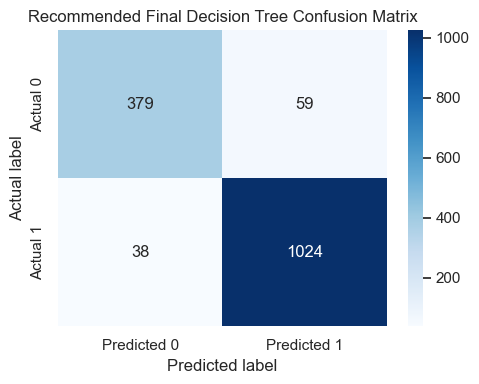

In [19]:
recommended_final_model = sensitivity_tree_model
recommended_final_X_test = X_sensitivity_test
recommended_final_y_test = y_sensitivity_test
recommended_final_feature_names = X_sensitivity.columns
recommended_final_metrics = sensitivity_metrics
recommended_final_predictions = recommended_final_model.predict(recommended_final_X_test)

print('Recommended final model metrics:')
display(pd.DataFrame([recommended_final_metrics]).round(4))

print('Classification report for recommended final model:')
print(classification_report(recommended_final_y_test, recommended_final_predictions, zero_division=0))

recommended_final_confusion_matrix = confusion_matrix(recommended_final_y_test, recommended_final_predictions)
plt.figure(figsize=(5, 4))
sns.heatmap(
    recommended_final_confusion_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
plt.title('Recommended Final Decision Tree Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.tight_layout()
plt.show()

### Recommended Final Decision Tree Structure

The recommended final decision tree can be visualized directly because tuning keeps it shallow enough to inspect. This plot shows the split rules, class counts, and predicted class at each node. It should be read as a model explanation, not as causal proof.

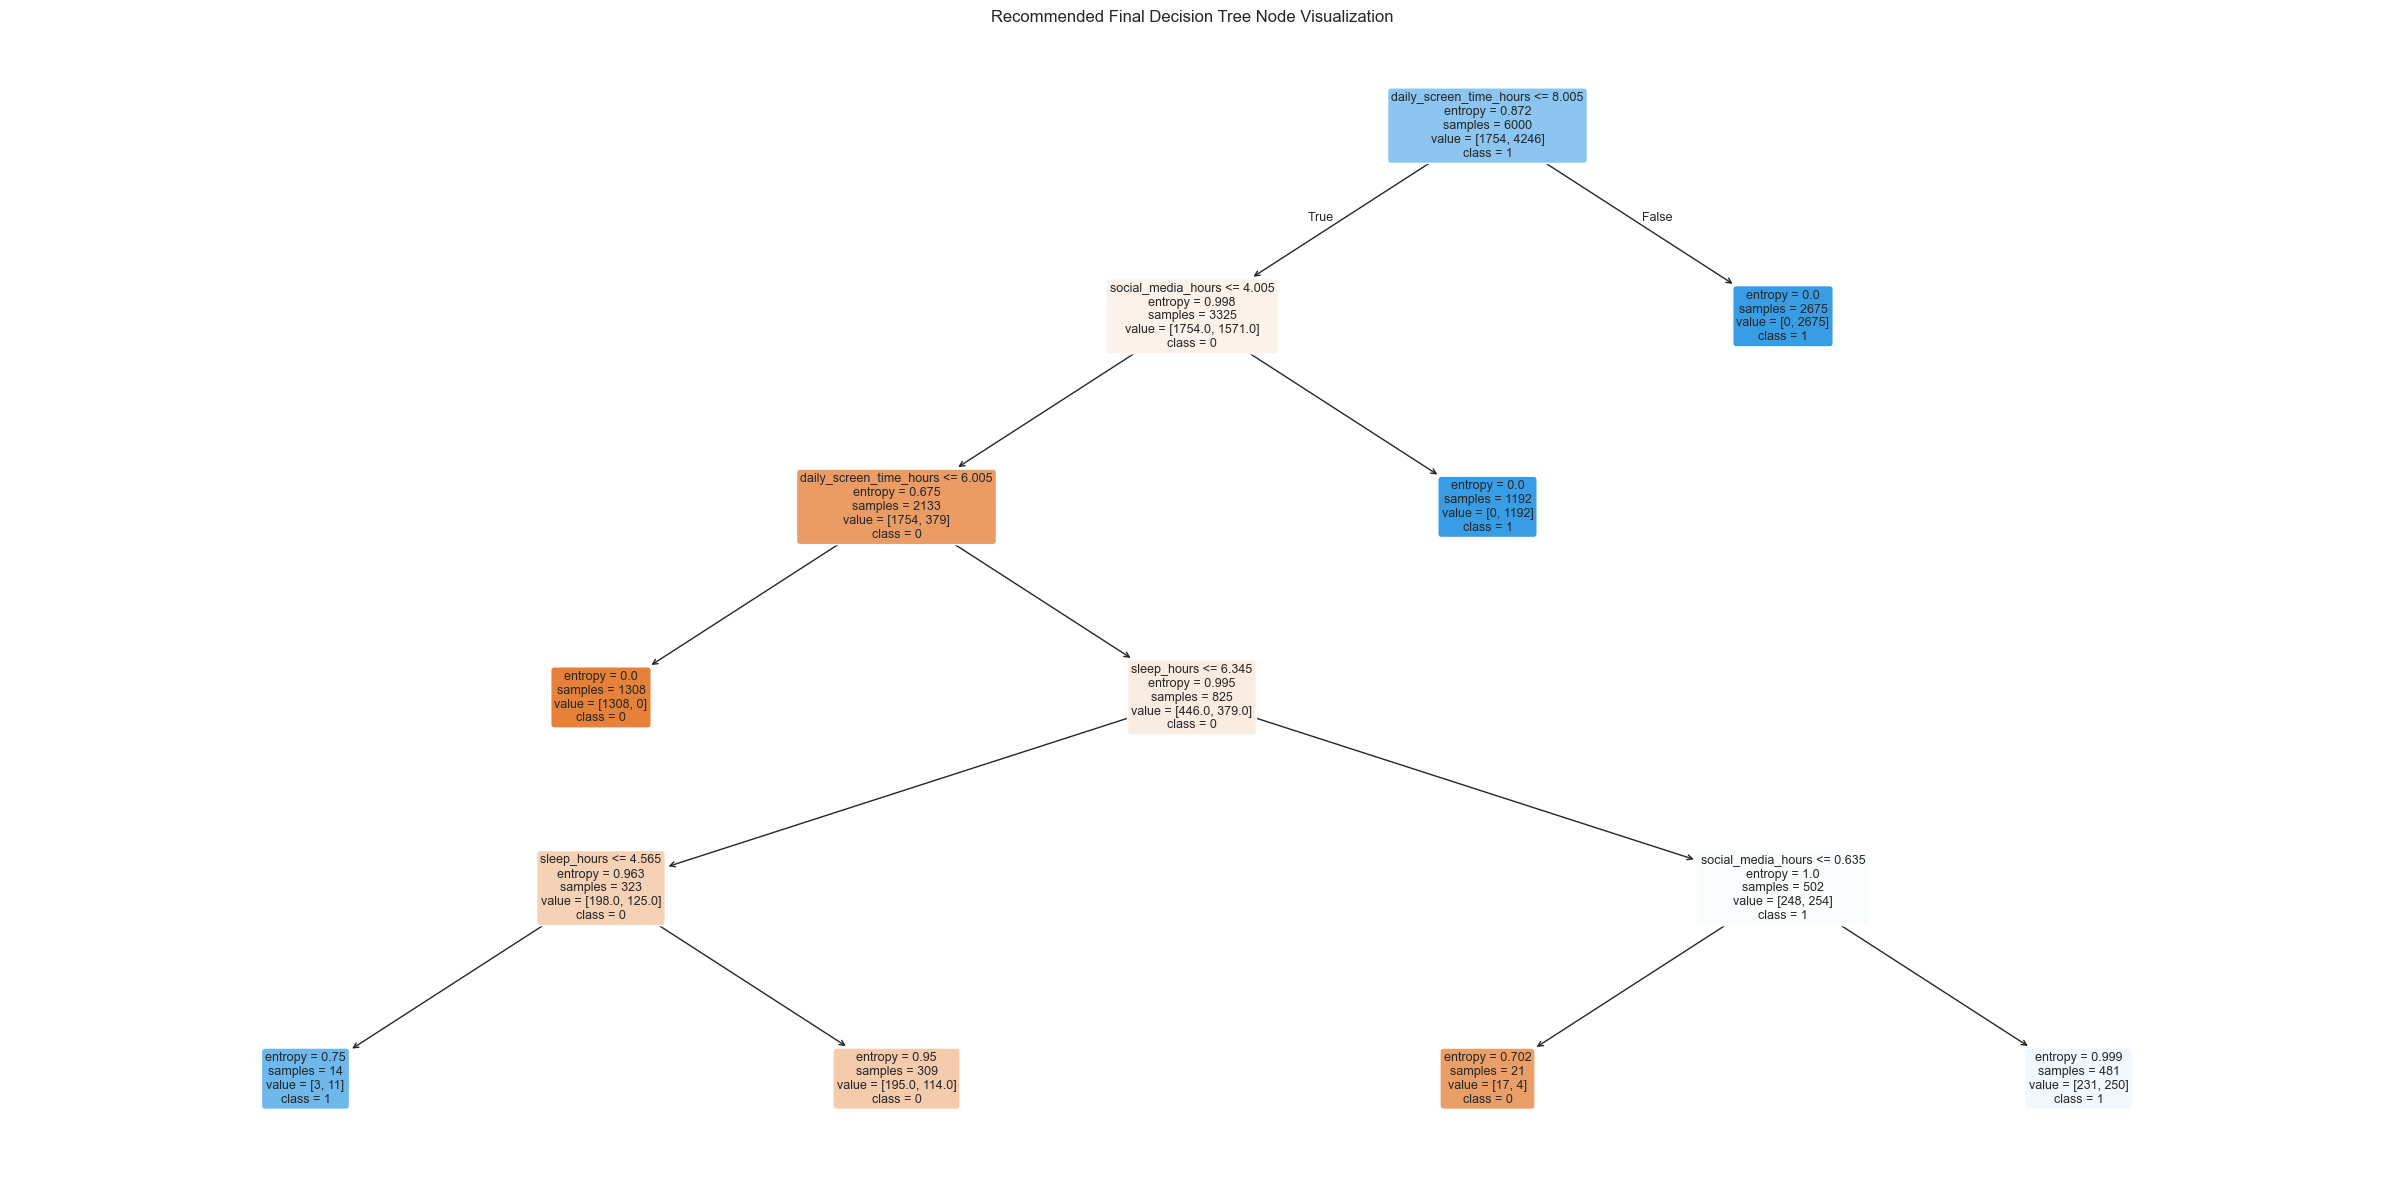

In [20]:
plt.figure(figsize=(24, 12))
plot_tree(
    recommended_final_model,
    feature_names=recommended_final_feature_names,
    class_names=['0', '1'],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    fontsize=9
)
plt.title('Recommended Final Decision Tree Node Visualization')
plt.tight_layout()
plt.show()

### Recommended Final Model Feature Importance

The decision tree's feature importance values help identify which variables contributed most to the selected model. These importances are model-specific, so they should be interpreted as predictive signals rather than causal effects.

Top 10 feature importances for the recommended final decision tree:


,feature,importance
0,daily_screen_time_hours,0.5712
1,social_media_hours,0.4253
2,sleep_hours,0.0034
3,age,0.0000
4,gaming_hours,0.0000
5,work_study_hours,0.0000
6,notifications_per_day,0.0000
7,app_opens_per_day,0.0000
8,weekend_screen_time,0.0000
9,sleep_below_7_hours,0.0000


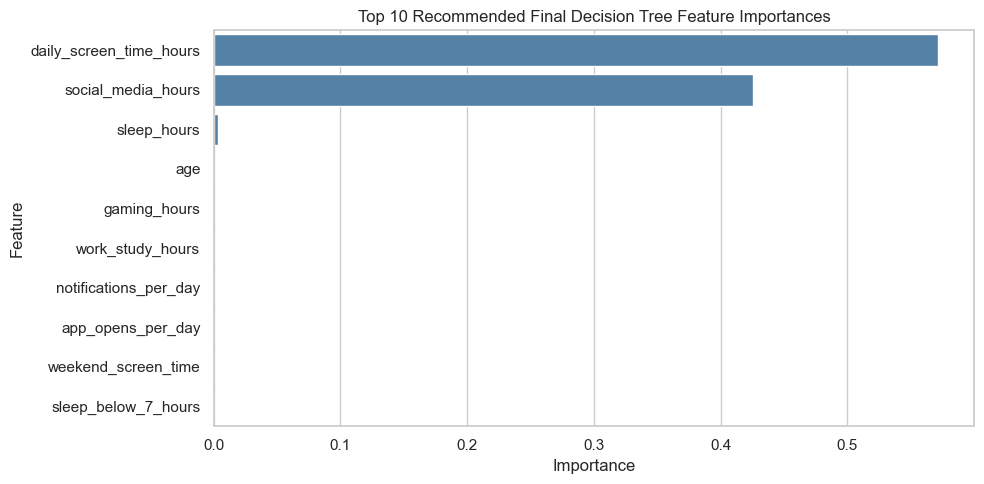

In [21]:
feature_importance_df = (
    pd.DataFrame({
        'feature': recommended_final_feature_names,
        'importance': recommended_final_model.feature_importances_
    })
    .sort_values(by='importance', ascending=False)
    .reset_index(drop=True)
)

print('Top 10 feature importances for the recommended final decision tree:')
display(feature_importance_df.head(10).round(4))

plt.figure(figsize=(10, 5))
sns.barplot(
    data=feature_importance_df.head(10),
    x='importance',
    y='feature',
    color='steelblue'
)
plt.title('Top 10 Recommended Final Decision Tree Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Person 4 Modeling Interpretation

1. Best model family: the decision tree was selected using training-only cross-validation because it had the strongest F1-score and remains explainable.
2. Recommended final model: the simpler tuned decision tree without aggregate/ratio engineered features is preferred because it performs slightly better and is easier to defend.
3. Final model performance: the recommended final decision tree achieved about 93.53% accuracy, 94.55% precision, 96.42% recall, 91.48% balanced accuracy, 95.48% F1-score, and 92.07% macro-F1 on the held-out test set.
4. Baseline comparison: the recommended final decision tree clearly beats the majority-class baseline, which mainly benefits from predicting the majority class and has no true negatives.
5. Confusion matrix interpretation: the recommended final decision tree produced 379 true negatives, 1,024 true positives, 59 false positives, and 38 false negatives.
6. Important features: the recommended final tree relies most heavily on screen-time and social-media-related variables.
7. Gender and addiction-level decision: gender showed weak association with the target and is excluded from modeling; `addiction_level` behaves as a target proxy and is also excluded.
8. Limitation: these results show prediction and association only. The model should not be interpreted as proving that any feature causes smartphone addiction, and it should not be used as a medical or clinical diagnosis tool.

### Person 4 Handoff to Final Summary

1. Best model name: recommended final tuned decision tree classifier using behavioral usage features, without gender, addiction level, or aggregate/ratio engineered features.
2. Key metrics: accuracy about 93.53%, precision about 94.55%, recall about 96.42%, balanced accuracy about 91.48%, F1-score about 95.48%, and macro-F1 about 92.07% on the held-out test set.
3. Main modeling conclusion: the non-leaking behavioral features can predict `addicted_label` much better than the majority-class baseline, especially using screen-time and social-media-related variables.
4. Gender decision: gender was tested before modeling and showed weak relationship with `addicted_label`, so it was dropped from the model instead of imputing or removing the `Other` category.
5. Addiction-level decision: `addiction_level` was excluded from the model because it behaves like a target proxy. Including it would create leakage and make the model look unrealistically strong.
6. Engineered-feature decision: the model without aggregate/ratio engineered features performed slightly better and is easier to explain, so it is recommended as the final model.
7. Recommended final-summary wording: describe the strongest variables as "predictive of" or "associated with" the target, not as causes.

## 5. Final Summary and Limitations - All

This analysis used the smartphone usage dataset to examine patterns associated with `addicted_label` and to test whether the label can be predicted using non-leaking behavioral features. The final prepared analysis keeps all 7,500 rows, including the `Other` gender category, because gender was not used as a model feature and did not need to be imputed or removed.

Cleaning found no duplicate rows, no duplicate `transaction_id`, and no duplicate `user_id`. The only source-column missingness was in `addiction_level`, with 819 missing values. These missing values are shown as `Not recorded` for descriptive EDA only; they are not imputed as a real severity category and are not used in the predictive model.

Preprocessing retained valid behavioral variables, created simple engineered usage features for exploration, and excluded leakage or non-modeling columns from `X`: `transaction_id`, `user_id`, `addicted_label`, `addiction_level`, `addiction_level_display`, and `gender`. The gender diagnostic showed weak relationship with the target, so gender was dropped from modeling while all rows were retained. The addiction-level diagnostic showed that `Not recorded` and `Mild` align with label `0`, while `Moderate` and `Severe` align with label `1`; this confirms that `addiction_level` behaves as a target proxy and must be excluded.

The strongest descriptive differences were in screen-time-related variables. Users with `addicted_label = 1` had higher average daily screen time, weekend screen time, and social media hours than users with `addicted_label = 0`. Stress level, academic/work impact, gender, sleep hours, notifications, and app opens showed weaker descriptive separation.

For predictive modeling, model-family selection was improved by using training-only cross-validation before held-out test reporting. The decision tree remained the selected model because it performed strongly and is explainable. A sensitivity check showed that removing the aggregate and ratio engineered features slightly improved performance and made the model simpler, so the recommended final model is the tuned decision tree without `usage_component_total_hours`, `notifications_per_screen_hour`, or `app_opens_per_screen_hour`.

The recommended final decision tree outperformed the majority-class baseline and achieved about 93.53% accuracy, 94.55% precision, 96.42% recall, 91.48% balanced accuracy, 95.48% F1-score, and 92.07% macro-F1 on the held-out test set. The notebook includes the final confusion matrix, feature importance chart, and a node-level visualization of the recommended final decision tree.

Important limitations: the dataset is observational, so findings are associated with or predictive of the target rather than causal. The model should not be used as a medical or clinical diagnosis tool. `weekend_screen_time` needs careful interpretation because its exact measurement basis is not fully validated. `addiction_level` appears to define or closely proxy the target, so it is useful only for descriptive checking and not for prediction. Feature importance values are model-specific and should not be interpreted as universal causal importance.

Future improvements could validate the dataset source, confirm the meaning of `weekend_screen_time`, test additional train/test splits or repeated cross-validation, use permutation importance for more robust feature interpretation, and compare simpler models if explainability is more important than small performance differences.